<a href="https://colab.research.google.com/github/deltorobarba/science/blob/main/adk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ADK Multi-Agent Pipeline with Vertex Services**

###### *New ADK Topics*

* ✅ Setup Vertex AI [Agent Engine](https://docs.cloud.google.com/agent-builder/agent-engine/overview) as runtime
* ✅ Build a pipeline with Parallel Agent and Sequential Agent
* ✅ Setup Vertex AI Session Service
* ✅ Setup Memory Service for long time memory
* ✅ Setup Vertex AI Search for Grounding with docs in Cloud Storage
* ✅ Use Google Search Tool
* ✅ Deploy Agents on Google Cloud
* ✅ Use custom (finetuned or fully managed) model from Vertex AI Model Garden
* ✅ Telemetry, Traceing, Observability
* ✅ Genmedia Agent with MCP
* ❌ Connect to MCP, OAuth, Gmail connect [MCP Server](https://developers.googleblog.com/introducing-the-developer-knowledge-api-and-mcp-server/). Also: [Data Science Agent](https://docs.cloud.google.com/colab/docs/use-data-science-agent) and [Developer Knowledge API](https://developers.google.com/knowledge/api)

[ADK Codelabs](https://codelabs.developers.google.com/onramp/instructions), [Multi-Agent Systems with ADK](https://cloud.google.com/blog/topics/developers-practitioners/building-collaborative-ai-a-developers-guide-to-multi-agent-systems-with-adk),
[ADK Integrations Ecosystem](https://developers.googleblog.com/en/supercharge-your-ai-agents-adk-integrations-ecosystem/)

###### *Setup and Environmental Variables*

In [ ]:
############################################
# Installs and Imports
############################################

!pip install google-adk mcp litellm -q
#!pip install --upgrade --quiet google-cloud-aiplatform[agent_engines,adk]>=1.112
!pip install --upgrade --quiet "google-cloud-aiplatform[agent_engines,adk]>=1.126.1" "google-adk>=1.18.0"

# Install the web server and BigQuery tools
!pip install -U google-cloud-aiplatform mcp uvicorn starlette sse-starlette google-cloud-bigquery --quiet

# Miscellaneous Tools
import warnings
warnings.filterwarnings('ignore')
from google.genai import types

# Agents
from google.adk.agents import LlmAgent, SequentialAgent, ParallelAgent

# ADK Tools (https://google.github.io/adk-docs/tools/)
from google.adk.tools import google_search, url_context, VertexAiSearchTool

# Session and Memory Services (https://google.github.io/adk-docs/sessions/memory/#configuration)
from google.adk.sessions import InMemorySessionService, VertexAiSessionService
from google.adk.memory import InMemoryMemoryService, VertexAiMemoryBankService
from google.adk.tools import load_memory

# Test Runner
import os
import asyncio
from google.adk.runners import Runner

# Vertex Services (general)
import vertexai
from vertexai import agent_engines

# Deployment, Traceing and Telemetry
from vertexai.preview import reasoning_engines

# Third party model
from google.adk.models.lite_llm import LiteLlm

In [ ]:
############################################
# Environmental Variables
############################################

# These tell the underlying google-genai client to use Vertex AI
os.environ["GOOGLE_GENAI_USE_VERTEXAI"] = "1"
os.environ["GOOGLE_CLOUD_PROJECT"] = "lunar-352813"
os.environ["GOOGLE_CLOUD_LOCATION"] = "us-central1"

# Required by LiteLLM for Vertex AI non-Gemini models
os.environ["VERTEXAI_PROJECT"] = "lunar-352813"
os.environ["VERTEXAI_LOCATION"] = "us-central1"

# Initialize Vertex AI client
client = vertexai.Client(project="lunar-352813", location="us-central1")

In [ ]:
############################################
# Vertex AI Services
############################################

# Vertex AI Search (Grounding) - Discovery Engine API is underlying engine, includes streamAssist
DATA_STORE_ID = "projects/lunar-352813/locations/global/collections/default_collection/dataStores/gemini-news-memory_1769533223752"

# Vertex AI Session Service (Chat History)
session_service = VertexAiSessionService(
    project="lunar-352813",
    location="us-central1",
    agent_engine_id="7707203776267943936"
)

# Vertex AI Memory Bank (User Facts)
memory_service = VertexAiMemoryBankService(
    project="lunar-352813",
    location="us-central1",
    agent_engine_id="7707203776267943936")

# Volatile (RAM) Session and Memory
# session_service = InMemorySessionService()
# memory_service = InMemoryMemoryService()

In [ ]:
############################################
# BigQuery with MCP (Colab local host)
############################################

# Bigquery authentification
from google.colab import auth
# 1. Authenticate (Pop-up will appear)
auth.authenticate_user()

In [ ]:
############################################
# Vertex AI Model as a Service (MaaS))
############################################

# Llama 4 Maverick
# https://docs.cloud.google.com/vertex-ai/generative-ai/docs/partner-models/llama/llama4-maverick?hl=de
llama = LiteLlm(
    model="vertex_ai/meta/llama-4-maverick-17b-128e-instruct-maas",
    #model="vertex_ai/projects/lunar-352813/locations/us-central1/endpoints/.." # as endpoint deployed instead of fully managed API
    vertex_project="lunar-352813",
    vertex_location="us-east5"    # some models are in another region!
)

# DeepSeek V3.2 MaaS on Vertex AI
# https://docs.cloud.google.com/vertex-ai/generative-ai/docs/maas/deepseek/deepseek-v32
deepseek = LiteLlm(
    model="vertex_ai/deepseek-ai/deepseek-v3.2-maas",
    vertex_project="lunar-352813",
    vertex_location="global"
)

# Kimi K2
# https://docs.cloud.google.com/vertex-ai/generative-ai/docs/maas/deepseek/deepseek-v32
kimi = LiteLlm(
    model="vertex_ai/kimi/kimi-k2-thinking-maas",
    vertex_project="lunar-352813",
    vertex_location="global"
)

# Qwen 3
# https://docs.cloud.google.com/vertex-ai/generative-ai/docs/maas/qwen/qwen3-next-thinking
qwen = LiteLlm(
    model="vertex_ai/qwen/qwen3-next-80b-a3b-thinking-maas",
    vertex_project="lunar-352813",
    vertex_location="global"
)

# Gemma 3
# https://pantheon.corp.google.com/vertex-ai/publishers/google/model-garden/gemma3
gemma = LiteLlm(
    model="vertex_ai/gemma3/gemma-3-1b-it",
    vertex_project="lunar-352813",
    vertex_location="us-central1"
)

###### ✅ *Colab Engine: Define and Test Agents including OSS Model*

In [ ]:
############################################
# Vertex AI Agent Engine (--> create once!)
############################################

# for VertexAiSessionService and VertexAiMemoryBankService
# ---> DO NOT START THIS AGAIN !!!!

"""
agent_engine = client.agent_engines.create(
    config={
        "display_name": "Research Agent Engine",
        "context_spec": {
            "memory_bank_config": {
                "generation_config": {
                    # This model handles memory extraction and consolidation
                    "model": "projects/lunar-352813/locations/us-central1/publishers/google/models/gemini-2.5-flash"
                }
            }
        }
    }
)

# Extract ID for code
print(f"Your Agent Engine ID: {agent_engine.api_resource.name.split('/')[-1]}")
"""

INFO:vertexai_genai.agentengines:View progress and logs at https://console.cloud.google.com/logs/query?project=lunar-352813&query=resource.type%3D%22aiplatform.googleapis.com%2FReasoningEngine%22%0Aresource.labels.reasoning_engine_id%3D%227707203776267943936%22.
INFO:vertexai_genai.agentengines:Agent Engine created. To use it in another session:
INFO:vertexai_genai.agentengines:agent_engine=client.agent_engines.get(name='projects/892203813305/locations/us-central1/reasoningEngines/7707203776267943936')


Your Agent Engine ID: 7707203776267943936


In [ ]:
############################################
# Agents and Workflow
############################################

# 1. Google Search Agent
web_agent = LlmAgent(
    name='web_researcher',
    model='gemini-2.5-flash',
    description=('Use GoogleSearchTool to find news latest news about Gemini and ChatGPT. Return only a list of URLs.'),
    instruction='Search for the latest public news on the topic.',
    tools=[google_search],
    output_key='search_results'
)

# 2. Vertex AI Search Agent
doc_agent = LlmAgent(
    name='internal_specialist',
    model='gemini-2.5-flash',
    instruction='''Search our internal knowledge base for related documents.
    If the tool returns no results, output EXACTLY: "NO INTERNAL DOCUMENTS FOUND".''',
    tools=[VertexAiSearchTool(data_store_id=DATA_STORE_ID)], # Vertex AI Search with DATA_STORE_ID
    output_key='internal_data'
)

# 3. Parallel Retrieval Agent
parallel_retrieval = ParallelAgent(
    name="parallel_retrieval",
    sub_agents=[web_agent, doc_agent]
)

# 4. Web Search Analysis Agent (Processes raw URLs)
search_analyst = LlmAgent(
    name='web_analyst',
    model='gemini-2.5-flash',
    instruction='''Use the url_context tool to read the URLs in {search_results}.
    Extract only technical specifications and performance benchmarks.''',
    tools=[url_context],
    output_key='web_analysis'
)

# 5. Deep Analysis Agent ("Brain")
analyst = LlmAgent(
    name='analyst',
    #model='gemini-2.5-pro',
    model=deepseek,
    #model=llama,
    description=('Compares Gemini 3 vs GPT-4o.'),
    instruction='''
    Check your memory for any user-specific instructions or past preferences.
    Compare public findings ({web_analysis}) against our private data ({internal_data}).
    Identify unique Gemini 3 features that GPT-4o lacks.
    ''',
    tools=[load_memory],  # Recall information from Vertex AI Memory Services!
    output_key='final_comparison'
)

# 6. CEO Summarizer Agent
summarizer = LlmAgent(
    name='summarizer',
    model='gemini-2.5-flash',
    description=('Draft concise summary'),
    instruction='''
    You are an Executive Intelligence Analyst.
    Summarize the findings in {final_comparison} into 5 punchy bullets for the CEO.
    Ensure you highlight contradictions between internal and public data.
    Max 2000 characters.
    ''',
)

# 7. Root Orchestrator (Master Flow)
root_agent = SequentialAgent(
    name='researcher',
    # no model needed
    # no instructions needed, it just moves data from 0 -> 1 -> 2 -> 3
    sub_agents=[parallel_retrieval, search_analyst, analyst, summarizer],
)

In [ ]:
############################################
# Test Agent (Colab Runtime)
############################################

APP_NAME="hybrid_news_app"
USER_ID="deltorobarba"

# Create persistent session + get session ID from Vertex AI:
new_session = await session_service.create_session(
    app_name=APP_NAME,
    user_id=USER_ID
)
active_session_id = new_session.id
print(f"New persistent session started with ID: {active_session_id}")

### Create hardcoded session ID only when volatile 'session_service = InMemorySessionService()' used
# active_session_id="session_01"
### Register custom ID before Runner can use it:
#await session_service.create_session(
#    app_name=APP_NAME,
#    user_id=USER_ID,
#    session_id=active_session_id)
#print(f"Volatile session started with custom ID: {active_session_id}")

# Formulate query for agents
query = "I'm CTO at Uluru Bank in Australia. Search for the latest 2026 news on Gemini 3 and compare its capabilities against GPT-4o."

# Initialize Runner
runner = Runner(
    agent=root_agent,
    app_name=APP_NAME,
    session_service=session_service,
    memory_service=memory_service # Connect to agent engine with agent_engine_id
    )

async def run_hybrid_flow():
    user_msg = types.Content(
        role="user",
        parts=[types.Part(text=query)])

    print(f"✅ Starting {root_agent.name} agent ..\n")

    # Modellnamen
    if hasattr(analyst.model, 'model'):
        # Case: LiteLlm Objekt
        model_name = analyst.model.model.split('/')[-1]
    else:
        # Case: Direkter String (z.B. bei Gemini)
        model_name = analyst.model
    print(f"Model for analyst agent: {model_name}\n")

    # Run agents
    async for event in runner.run_async(user_id=USER_ID, session_id=active_session_id, new_message=user_msg):
        if event.is_final_response() and event.content and event.author == "summarizer":
            print(f"{event.content.parts[0].text}")

    # Save to Memory
    updated_session = await runner.session_service.get_session(
        app_name=APP_NAME,
        user_id=USER_ID,
        session_id=active_session_id)

    # Sends entire chat transcript to specialized "Extractor" model. Reads conversation, extracts unique facts and save them.
    await memory_service.add_session_to_memory(updated_session)
    print("\n✅ [System] Finished. Memory extraction triggered.")

# Run the consolidated function
await run_hybrid_flow()

New persistent session started with ID: 3840408435795427328
✅ Starting researcher agent ..

Model for analyst agent: deepseek-v3.2-maas

Here are 5 key points for the CEO:

*   **Conflicting Gemini 3 Reality:** Our internal specialist indicates a "quantum telepathy" service for quantum data, starkly contrasting public releases of Gemini 3.x as a broad AI suite (Pro, Flash, 3.1 Pro) focused on massive context windows and video analysis.
*   **Gemini 3.x for Scale & Cost:** The public Gemini 3.x offers a massive 1-2 million token context window and is significantly cheaper ($1.25/1M tokens) than GPT-4o for input, making it ideal for large financial reports, strategic analysis, and Google ecosystem integration.
*   **GPT-4o for Precision & Interaction:** Despite being retired from ChatGPT, GPT-4o remains available via API, excelling in precision financial modeling, superior code generation, and real-time, human-like voice interactions for customer service.
*   **Recommended Hybrid Strateg

###### ✅ *Agent Engine: Define, Deploy and Test Agents*

In [ ]:
############################################
# 1. Define Agents and Workflow
############################################

# 1. Google Search Agent
web_agent = LlmAgent(
    name='web_researcher',
    model='gemini-2.5-flash',
    description=('Use GoogleSearchTool to find news latest news about Gemini and ChatGPT. Return only a list of URLs.'),
    instruction='Search for the latest public news on the topic.',
    tools=[google_search],
    output_key='search_results'
)

# 2. Vertex AI Search Agent
doc_agent = LlmAgent(
    name='internal_specialist',
    model='gemini-2.5-flash',
    instruction='''Search our internal knowledge base for related documents.
    If the tool returns no results, output EXACTLY: "NO INTERNAL DOCUMENTS FOUND".''',
    tools=[VertexAiSearchTool(data_store_id=DATA_STORE_ID)], # Vertex AI Search with DATA_STORE_ID
    output_key='internal_data'
)

# 3. Parallel Retrieval Agent
parallel_retrieval = ParallelAgent(
    name="parallel_retrieval",
    sub_agents=[web_agent, doc_agent]
)

# 4. Web Search Analysis Agent (Processes raw URLs)
search_analyst = LlmAgent(
    name='web_analyst',
    model='gemini-2.5-flash',
    instruction='''Use the url_context tool to read the URLs in {search_results}.
    Extract only technical specifications and performance benchmarks.''',
    tools=[url_context],
    output_key='web_analysis'
)

# 5. Deep Analysis Agent ("Brain")
analyst = LlmAgent(
    name='analyst',
    model='gemini-2.5-pro',
    description=('Compares Gemini 3 vs GPT-4o.'),
    instruction='''
    Check your memory for any user-specific instructions or past preferences.
    Compare public findings ({web_analysis}) against our private data ({internal_data}).
    Identify unique Gemini 3 features that GPT-4o lacks.
    ''',
    tools=[load_memory],  # Recall information from Vertex AI Memory Services!
    output_key='final_comparison'
)

# 6. CEO Summarizer Agent
summarizer = LlmAgent(
    name='summarizer',
    model='gemini-2.5-flash',
    description=('Draft concise summary'),
    instruction='''
    You are an Executive Intelligence Analyst.
    Summarize the findings in {final_comparison} into 5 punchy bullets for the CEO.
    Ensure you highlight contradictions between internal and public data.
    Max 2000 characters.
    ''',
)

# 7. Root Orchestrator (Master Flow)
root_agent = SequentialAgent(
    name='researcher',
    # no model needed
    # no instructions needed, it just moves data from 0 -> 1 -> 2 -> 3
    sub_agents=[parallel_retrieval, search_analyst, analyst, summarizer],
)

In [ ]:
############################################
# 2. Deploy Agents Google Cloud (modern, with agentengine framework)
############################################

"""
Permissions: Take the AI Platform Reasoning Engine Service Agent that the agent uses:
'service-892203813305@gcp-sa-aiplatform-re.iam.gserviceaccount.com'.
Go to IAM, enable 'Include Google-provided role grants' and add role: 'Discovery Engine Viewer', 'Vertex AI User' and 'Cloud Trace Agent' (write)
Troubleshooting: https://docs.cloud.google.com/agent-builder/agent-engine/troubleshooting/use

Traceing and Logging:
* Cloud Logging API in GCP project aktivieren
* Telemetry API in GCP project aktivieren
* Add role 'Cloud Trace Agent' (write) to service account
* https://docs.cloud.google.com/agent-builder/agent-engine/manage/tracing
* https://docs.cloud.google.com/agent-builder/agent-engine/deploy
"""

# Create GCS bucket first if you haven't already
STAGING_BUCKET = "gs://lunar-352813-agent-staging"

# https://google.github.io/adk-docs/deploy/agent-engine/deploy/#setup-cloud-project
# https://docs.cloud.google.com/agent-builder/agent-engine/develop/custom
# Environmental Variables for Traceing (https://docs.cloud.google.com/agent-builder/agent-engine/deploy)
# Set env variables (https://docs.cloud.google.com/agent-builder/agent-engine/manage/tracing)
custom_env_vars = {
    "GOOGLE_CLOUD_AGENT_ENGINE_ENABLE_TELEMETRY": "true",
    "OTEL_INSTRUMENTATION_GENAI_CAPTURE_MESSAGE_CONTENT": "true",
}

# 1. Initialize the client
client = vertexai.Client(project="lunar-352813", location="us-central1")

# 2. Wrap the agent
adk_app = reasoning_engines.AdkApp(
    agent=root_agent,
    enable_tracing=True,
    env_vars=custom_env_vars
)

# 3. Deploy
remote_agent = client.agent_engines.create(
    agent=adk_app,
    config={
        # This tells Vertex AI where to upload your agent's code
        "staging_bucket": STAGING_BUCKET,

        "requirements": [
            "google-cloud-aiplatform[agent_engines,adk]>=1.135",
            "google-adk>=1.23.0",
            "google-cloud-trace"
        ],
        "env_vars":custom_env_vars,
        "display_name":"Research Agent Engine (Live Llama)",
        "context_spec": {
            "memory_bank_config": {
                "generation_config": {
                    "model": f"projects/lunar-352813/locations/us-central1/publishers/google/models/gemini-2.5-flash"
                }
            }
        }
    },
)

INFO:vertexai_genai.agentengines:Identified the following requirements: {'cloudpickle': '3.1.0', 'pydantic': '2.12.5', 'google-cloud-aiplatform': '1.135.0'}
INFO:vertexai_genai.agentengines:The following requirements are appended: {'cloudpickle==3.1.0', 'pydantic==2.12.5'}
INFO:vertexai_genai.agentengines:The final list of requirements: ['google-cloud-aiplatform[agent_engines,adk]>=1.135', 'google-adk>=1.23.0', 'google-cloud-trace', 'cloudpickle==3.1.0', 'pydantic==2.12.5']
INFO:vertexai_genai.agentengines:Using bucket lunar-352813-agent-staging
INFO:vertexai_genai.agentengines:Wrote to gs://lunar-352813-agent-staging/agent_engine/agent_engine.pkl
INFO:vertexai_genai.agentengines:Writing to gs://lunar-352813-agent-staging/agent_engine/requirements.txt
INFO:vertexai_genai.agentengines:Creating in-memory tarfile of extra_packages
INFO:vertexai_genai.agentengines:Writing to gs://lunar-352813-agent-staging/agent_engine/dependencies.tar.gz
INFO:vertexai_genai.agentengines:Using agent framew

In [ ]:
############################################
# 3a. Test Agent (Agent Engine Runtime)
############################################

# -----> Initial Query

# 1. Initialize the client
client = vertexai.Client(project="lunar-352813", location="us-central1")

# 2. Remote app handle
RESOURCE_NAME = "projects/892203813305/locations/us-central1/reasoningEngines/2753672995695230976"
remote_app = client.agent_engines.get(name=RESOURCE_NAME)

async def run_remote_test():
    print(f"Connecting to: {RESOURCE_NAME}...")
    user_id = "deltorobarba"

    # 3. Create session and grab the 'id' key specifically 🔑
    raw_session = await remote_app.async_create_session(user_id=user_id)

    # Based on your last error, the key is definitely 'id'
    session_id = raw_session.get('id')

    if not session_id:
        print(f"❌ Error: ID not found in response: {raw_session}")
        return

    print(f"✅ Created Managed Session ID: {session_id}")

    # 4. Stream the query (nur Summarizer-Events anzeigen) 🌊
    async for event in remote_app.async_stream_query(
        user_id=user_id,
        session_id=session_id,
        message="Uluru bank uses ChatGPT. The annual revenue of Uluru bank is 500 Mio USD. Search news on Gemini 3 and compare it to GPT-4o."
    ):
        # Filtern nach dem Author 'summarizer' 🔍
        # if 'content' in event: # print every agent's output
        if event.get('author') == 'summarizer' and 'content' in event:
            for part in event['content'].get('parts', []):
                if 'text' in part:
                    print(f"\n--- Agent Output (Summary Agent) ---\n{part['text']}")

    # 5. Trigger Memory Extraction 🧠
    print(f"\n[System] Fetching session state for extraction...")
    current_session = await remote_app.async_get_session(
        user_id=user_id,
        session_id=session_id
    )

    # Check for events to ensure history is captured
    # Docs: https://google.github.io/adk-docs/events/#extracting-key-information
    if current_session.get('events'):
        print(f"✅ Found {len(current_session['events'])} events. Sending to Memory Bank...")
        # Pass the dictionary directly to the memory service
        await remote_app.async_add_session_to_memory(session=current_session)
        print("\n[Done] Memory extraction triggered! Check 'Gemerkte Informationen' in 1-2 mins.")
    else:
        print("\n❌ Error: Session history was empty. No memories extracted.")

# Execute
await run_remote_test()

Connecting to: projects/892203813305/locations/us-central1/reasoningEngines/2753672995695230976...
✅ Created Managed Session ID: 9199691992366317568

--- Agent Output (Summary Agent) ---
Here are the key findings on Gemini 3's unique features compared to GPT-4o, with critical contradictions highlighted:

*   **Contradiction: Gemini 3's Public Reality vs. Internal Scope:** While an internal Google document solely highlights "Gemini 3's" future "quantum telepathy" service (lacking in GPT-4o), public data confirms multiple general-purpose Gemini 3 models (Pro, Flash) are already available or launching soon (late 2025/early 2026), directly competing with GPT-4o across broader AI capabilities.
*   **Vastly Larger Context Window:** Gemini 3 Pro and 2.5 Pro boast an 8x larger context window (1 million tokens) than GPT-4o's 128,000, enabling processing of far larger datasets and more complex, sustained interactions.
*   **Superior Performance & Fresher Data:** Gemini 3 variants consistently ou

In [ ]:
############################################
# 3b. Test Agent (Agent Engine Runtime)
############################################

# -----> Follow Up Query

import vertexai

# 1. Initialize the client
client = vertexai.Client(project="lunar-352813", location="us-central1")

# 2. Remote app handle
RESOURCE_NAME = "projects/892203813305/locations/us-central1/reasoningEngines/2753672995695230976"
remote_app = client.agent_engines.get(name=RESOURCE_NAME)

async def run_follow_up():
    print(f"Resuming Session on: {RESOURCE_NAME}...")
    user_id = "deltorobarba"

    # 3. Explicitly reuse your Session ID from the first run! <-------- copy/paste existing session ID !!!
    session_id = "1822255942524207104"

    print(f"✅ Reusing Managed Session ID: {session_id}")

    # 4. Stream the follow-up query 🌊
    # The agent will remember the Uluru Bank details from the first query.
    async for event in remote_app.async_stream_query(
        user_id=user_id,
        session_id=session_id,
        message="How can I use Gemini 3 in financial services"
        # message="Based on that revenue, which Gemini 3 model (Pro or Flash) is more cost-effective for us?"
    ):
        if event.get('author') == 'summarizer' and 'content' in event:
            for part in event['content'].get('parts', []):
                if 'text' in part:
                    print(f"\n--- Agent Output (Summary Agent) ---\n{part['text']}")

    # 5. Optional: Trigger Memory Extraction again 🧠
    # This will now include the context from both queries.
    current_session = await remote_app.async_get_session(user_id=user_id, session_id=session_id)
    if current_session.get('events'):
        print(f"\n✅ Found {len(current_session['events'])} total events across both turns.")
        await remote_app.async_add_session_to_memory(session=current_session)

# Execute the second run
await run_follow_up()

Resuming Session on: projects/892203813305/locations/us-central1/reasoningEngines/2753672995695230976...
✅ Reusing Managed Session ID: 1822255942524207104

--- Agent Output (Summary Agent) ---
Uluru Bank can leverage Gemini 3's advanced capabilities across its operations to significantly enhance efficiency, strategy, and security:

*   **Supercharge Compliance & Risk Management:** Utilize Gemini 3's 1 million-token context window to analyze thousands of pages of contracts, regulatory filings, and transactional data in minutes. This will drastically improve fraud detection, identify subtle risks, and ensure compliance with unprecedented speed and accuracy, aided by its enhanced security features.
*   **Revolutionize Customer Experience & Advisory:** Deploy Gemini 3's multimodal capabilities (text, audio, video) for highly personalized financial advisory and customer service. It can analyze complete client histories to offer tailored advice and power sophisticated, natural-sounding chatb

In [ ]:
############################################
# 3c. Test Agent (Agent Engine Runtime)
############################################

# -----> Multi-Turn Query

async def run_multi_turn_test():
    print(f"Connecting to: {RESOURCE_NAME}...")
    user_id = "deltorobarba"

    # --- Turn 1: Initial Query (Creates the Session) ---
    raw_session = await remote_app.async_create_session(user_id=user_id)
    session_id = raw_session.get('id')
    print(f"✅ Session Created: {session_id}")

    # First Message
    await execute_query(user_id, session_id, "Uluru bank uses ChatGPT. Annual revenue is 500 Mio USD. Compare Gemini 3 to GPT-4o.")

    # --- Turn 2: Follow-up Query (Reuses the Session ID) ---
    print(f"\n--- Starting Follow-up Query in Session: {session_id} ---")

    # Notice we use the SAME session_id variable here!
    await execute_query(user_id, session_id, "Based on that revenue, which model is more cost-effective for us?")

    # --- Step 5: Final Memory Extraction ---
    # Fetching the session now will show events from BOTH queries.
    current_session = await remote_app.async_get_session(user_id=user_id, session_id=session_id)
    if current_session.get('events'):
        print(f"✅ Found {len(current_session['events'])} total events. Extracting to Memory Bank...")
        await remote_app.async_add_session_to_memory(session=current_session)

# Helper function to keep the code clean
async def execute_query(user_id, session_id, message):
    async for event in remote_app.async_stream_query(
        user_id=user_id,
        session_id=session_id,
        message=message
    ):
        if event.get('author') == 'summarizer' and 'content' in event:
            for part in event['content'].get('parts', []):
                if 'text' in part:
                    print(f"\n[Summarizer]: {part['text']}")

await run_multi_turn_test()

Connecting to: projects/892203813305/locations/us-central1/reasoningEngines/2753672995695230976...
✅ Session Created: 6978877515863425024

[Summarizer]: Here are 5 key points for the CEO:

*   **Clarifying Gemini:** While "Gemini 3" is often a conceptual term (e.g., "quantum telepathy"), Google's current *Gemini 3 Pro* and *2.5 Pro* are available and offer significant, immediate upgrades over GPT-4o for Uluru Bank's operations.
*   **Unmatched Data Insight:** Gemini's superior reasoning and vast 1M+ token context window (vs. GPT-4o's 128K) enable deeper, contextual analysis of entire financial reports, legal documents, and market trends, providing critical insights.
*   **Accelerated Innovation:** Gemini excels in code generation, capable of building entire internal applications and interactive UIs from a single prompt, drastically speeding up development of bespoke banking tools and dashboards.
*   **Precision & Multimodality:** Features like "Deep Think" mode and "best-in-world" mult

###### ✅ *Colab Engine: MCP and BigQuery*

In [ ]:
############################################
# 1. Create Server Code
# Write bq_server.py file that defines BQ tool and wraps it in web server (Starlette + Uvicorn)
############################################

%%writefile bq_server.py
import uvicorn
from starlette.applications import Starlette
from starlette.responses import Response
from starlette.routing import Route
from mcp.server.sse import SseServerTransport
from mcp.server import Server
import mcp.types as types
from google.cloud import bigquery

# 1. Initialize Server
server = Server("bigquery-analyst")

"""
a) The Engine
We write a simple Python function (`execute_query`) that takes a SQL string,
sends it to Google BigQuery, and returns up to 20 rows of data.
We added a safety check to block modification queries (`DROP`, `DELETE`, etc.).
"""

# 2. Define Tool Logic
def execute_query(sql_query: str) -> str:
    forbidden = ["DROP", "DELETE", "INSERT", "UPDATE", "ALTER", "TRUNCATE"]
    if any(cmd in sql_query.upper() for cmd in forbidden):
        return "Error: Modification queries are not allowed. Read-only access."

    try:
        client = bigquery.Client()
        query_job = client.query(sql_query)
        # Limit to 20 rows to avoid blowing up the context window
        results = [dict(row) for row in query_job.result()]

        if not results:
            return "Query executed successfully but returned no results."

        return str(results[:20])
    except Exception as e:
        return f"BigQuery Error: {str(e)}"

"""
b) The MCP Wrapper
* We wrap the `execute_query` function using the `mcp.server` library.
* `@server.list_tools()`: This is the server advertising its capabilities. It tells any connected client:
   "I have a tool called `query_public_dataset`. It requires a `sql_query` string."
* `@server.call_tool()`: This is the execution endpoint. When a client says "Run `query_public_dataset` with
    this SQL," this function triggers our BigQuery engine.
"""

# 3. Register Tool
@server.list_tools()
async def handle_list_tools() -> list[types.Tool]:
    return [
        types.Tool(
            name="query_public_dataset",
            description="Run a read-only SQL query against BigQuery public datasets.",
            inputSchema={
                "type": "object",
                "properties": {
                    "sql_query": {"type": "string", "description": "The SQL query to execute"}
                },
                "required": ["sql_query"]
            }
        )
    ]

@server.call_tool()
async def handle_call_tool(name: str, arguments: dict | None) -> list[types.TextContent | types.ImageContent | types.EmbeddedResource]:
    if name == "query_public_dataset":
        if not arguments or "sql_query" not in arguments:
            raise ValueError("Missing sql_query argument")
        result = execute_query(arguments["sql_query"])
        return [types.TextContent(type="text", text=result)]
    raise ValueError(f"Unknown tool: {name}")

"""
c) The Network Layer
* We used `Starlette` and `uvicorn` to wrap this MCP server into a standard HTTP web server,
  listening on port 8000 using Server-Sent Events (SSE)
"""

# 4. Web Server Logic
sse = SseServerTransport("/messages")

async def handle_sse(request):
    async with sse.connect_sse(request.scope, request.receive, request._send) as streams:
        await server.run(streams[0], streams[1], server.create_initialization_options())
    return Response()

async def handle_messages(request):
    # Unpack the request into raw ASGI components
    await sse.handle_post_message(request.scope, request.receive, request._send)

# Define routes
routes = [
    Route("/sse", endpoint=handle_sse),
    Route("/messages", endpoint=handle_messages, methods=["POST"])
]

app = Starlette(debug=True, routes=routes)

if __name__ == "__main__":
    uvicorn.run(app, host="0.0.0.0", port=8000)
"""
Because the standalone database querying API (server) and ADK Agent (client) communicate via MCP,
we could host this `bq_server.py` on a completely different machine, or even write it in a  different language
like TypeScript, and the ADK agent would still be able to use it without any agent code change !!
"""

Overwriting bq_server.py


In [ ]:
############################################
# 2. Launch MCP Server
# Use a background process to start running bq_server.py on port 8000
############################################

"""
Running the Server: proc = subprocess.Popen(["python", "bq_server.py"], stdout=log, stderr=log)
We launched that server in the background of your notebook. It sits there, quietly listening
on `http://localhost:8000/sse`, waiting for an AI to connect to it.
"""

import subprocess
import time
import requests

!fuser -k 8000/tcp > /dev/null 2>&1

print("🚀 Restarting BigQuery MCP Server...")
with open("server.log", "w") as log:
    proc = subprocess.Popen(["python", "bq_server.py"], stdout=log, stderr=log)

print("Waiting for initialization...")
time.sleep(5)

try:
    response = requests.get("http://localhost:8000/sse", stream=True, timeout=2)
    print(f"✅ Server is UP! (Status: {response.status_code})")
except requests.exceptions.Timeout:
    print("✅ Server is UP and listening!")
except Exception as e:
    print(f"❌ Server check failed: {e}")

🚀 Restarting BigQuery MCP Server...
Waiting for initialization...
✅ Server is UP! (Status: 200)


In [ ]:
############################################
# 3. Call MCP to connect to BigQuery with ADK
############################################

import time
from google.adk.tools.mcp_tool.mcp_toolset import MCPToolset
from google.adk.tools.mcp_tool import SseConnectionParams
from google.adk.tools.mcp_tool.mcp_session_manager import SseConnectionParams
from google.genai import types as genai_types

"""
1. The Connection: We told the ADK where to find our server using `SseConnectionParams`.
2. The Toolset: We created an `MCPToolset`. When this is initialized, the ADK reaches out to port 8000,
   reads the advertisement (`list_tools()`), and learns that it can execute BigQuery SQL.
3. The Agent: We created `enterprise_agent`, powered by Gemini 2.0 Flash. We gave it instructions
   ("You are a Data Analyst...") and, we handed it the `mcp_bq_tools`.
"""

# 1. Define Connection
bq_params = SseConnectionParams(
    url="http://0.0.0.0:8000/sse"
)

# 2. Create Toolset
mcp_bq_tools = MCPToolset(connection_params=bq_params)

# 3. Create Agent
enterprise_agent = LlmAgent(
    name='bigquery_analyst',
    model='gemini-2.5-flash',
    instruction="""
    You are an Enterprise Data Analyst.
    You have access to Google BigQuery public datasets.
    When asked a question:
    1. Formulate a correct BigQuery SQL query.
    2. Use the 'query_public_dataset' tool to execute it.
    3. Summarize the findings for the user.
    """,
    tools=[mcp_bq_tools]
)

"""
The Execution Loop
* Question: "What were the top 3 most popular female names...?"
* Model thinking: Gemini reads the question. It realizes it doesn't know the answer off the top of its head,
  but it knows that it has a tool called `query_public_dataset` that requires SQL.
* Function Call: Gemini pauses its text generation. Instead of returning a text answer, it returns a Function Call
  (this is what triggered the `WARNING: there are non-text parts in the response: ['function_call']`).
  It tells the Runner: *"Please execute `query_public_dataset` with this SQL: `SELECT name, number
  FROM \`bigquery-public-data.usa_names.usa_1910_2013` WHERE year = 1980 AND gender = 'F' ORDER BY number DESC LIMIT 3`."*
* The Runner Intercepts: The ADK Runner catches that function call. It forwards the request over HTTP to
  the `bq_server.py` running in the background.
* Execution: The server executes the SQL against BigQuery, gets the results (Jennifer, Amanda, Jessica),
  and sends them back to the Runner.
* Final Answer: The Runner feeds those raw results back to Gemini. Gemini sees the data, formulates a polite,
  readable sentence, and sends you the final text output.
"""

# 4. Setup Runner
APP_NAME = "bq-demo-app"
USER_ID = "demo-user"

bq_runner = Runner(
    agent=enterprise_agent,
    session_service=session_service,
    app_name=APP_NAME,
)

# 5. Create Session (Letting Vertex generate the ID)
try:
    new_session = await session_service.create_session(
        app_name=APP_NAME,
        user_id=USER_ID
    )

    # 💡 Accessing .id instead of .session_id
    active_session_id = new_session.id

    print(f"✅ Created new session: {active_session_id}")
except AttributeError:
    # If .id is STILL wrong, let's dump the object so we can see what's actually inside it!
    print(f"❌ Attribute error. Let's look inside the Session object:\n{new_session.__dict__}")
    raise
except Exception as e:
    print(f"❌ Failed to create session. Error: {e}")
    raise

"""
Microservice Architecture -
We have built two completely separate applications inside one notebook:
1. A standalone database querying API (the Server).
2. An AI Agent that consumes APIs (the Client).
"""

# 6. Ask the Question
question = "What were the top 3 most popular female names in the USA in 1980? Query the 'bigquery-public-data.usa_names.usa_1910_2013' table."

print(f"🤖 User: {question}\n")

# Use the factory method to ensure proper API serialization
user_msg = genai_types.Content(
    role="user",
    parts=[genai_types.Part.from_text(text=question)]
)

async for event in bq_runner.run_async(
    user_id=USER_ID,
    session_id=active_session_id, # Use the ID generated in Step 4
    new_message=user_msg
):
    if event.is_final_response() and event.content:
        # Check if parts exist before printing
        if event.content.parts:
            print(f"🕵️ Analyst: {event.content.parts[0].text}")

✅ Created new session: 3479444815710519296
🤖 User: What were the top 3 most popular female names in the USA in 1980? Query the 'bigquery-public-data.usa_names.usa_1910_2013' table.

🕵️ Analyst: In 1980, the top 3 most popular female names in the USA were:

1.  **Jennifer** with 58,385 occurrences.
2.  **Amanda** with 35,818 occurrences.
3.  **Jessica** with 33,920 occurrences.


###### ✅ *Colab Engine: MCP and GenMedia: Imagen (images), Veo (video), Chirp (audio), and Lyria (music)*

In [ ]:
import subprocess
import time
import os
import base64
from IPython.display import Image, display

from google.adk.agents import LlmAgent
from google.adk.runners import Runner
from google.adk.sessions import InMemorySessionService
from google.adk.tools.mcp_tool.mcp_toolset import MCPToolset, SseConnectionParams
from google.genai import types as genai_types

In [ ]:
############################################
#  Create Imagen MCP Server
############################################

# https://google.github.io/adk-docs/mcp/#mcp-servers-for-google-cloud-genmedia
# https://github.com/GoogleCloudPlatform/vertex-ai-creative-studio/blob/main/experiments/mcp-genmedia/sample-agents/adk/genmedia_agent/agent.py
# https://github.com/GoogleCloudPlatform/vertex-ai-creative-studio

# ----> chirp3, veo3, avtool

%%writefile imagen_server.py
import uvicorn
import base64
import os
import vertexai
from starlette.applications import Starlette
from starlette.responses import Response
from starlette.routing import Route
from mcp.server.sse import SseServerTransport
from mcp.server import Server
import mcp.types as types
from vertexai.preview.vision_models import ImageGenerationModel

# 1. Setup Vertex AI
PROJECT_ID = os.getenv("GOOGLE_CLOUD_PROJECT")
vertexai.init(project=PROJECT_ID)

# 2. Setup MCP Server
server = Server("imagen-server")

@server.list_tools()
async def handle_list_tools() -> list[types.Tool]:
    return [types.Tool(
        name="generate_image",
        description="Generates an image from a prompt.",
        inputSchema={
            "type": "object",
            "properties": {"prompt": {"type": "string"}},
            "required": ["prompt"]
        }
    )]

@server.call_tool()
async def handle_call_tool(name: str, arguments: dict | None) -> list[types.TextContent]:
    if name == "generate_image":
        prompt = arguments.get("prompt", "a cat")
        model = ImageGenerationModel.from_pretrained("imagen-3.0-generate-001")
        images = model.generate_images(prompt=prompt, number_of_images=1)

        # Save the image locally instead of sending base64 over the wire
        file_name = "output_image.png"
        with open(file_name, "wb") as f:
            f.write(images[0]._image_bytes)

        # Return a tiny text string back to the LLM context
        return [types.TextContent(
            type="text",
            text=f"Success! Image generated and saved locally as '{file_name}'."
        )]
    raise ValueError(f"Unknown tool: {name}")

# 3. Network/SSE Logic
sse = SseServerTransport("/messages")

async def handle_sse(request):
    async with sse.connect_sse(request.scope, request.receive, request._send) as streams:
        await server.run(streams[0], streams[1], server.create_initialization_options())
    return Response()

async def handle_messages(request):
    await sse.handle_post_message(request.scope, request.receive, request._send)
    return Response(status_code=202)

app = Starlette(debug=True, routes=[
    Route("/sse", endpoint=handle_sse),
    Route("/messages", endpoint=handle_messages, methods=["POST"])
])

if __name__ == "__main__":
    uvicorn.run(app, host="0.0.0.0", port=8001)

Overwriting imagen_server.py


In [ ]:
############################################
# Create VEO MCP Server
############################################

# https://docs.cloud.google.com/vertex-ai/generative-ai/docs/models/veo/3-0-generate

%%writefile veo_server.py
import uvicorn
import os
import asyncio
from starlette.applications import Starlette
from starlette.responses import Response
from starlette.routing import Route
from mcp.server.sse import SseServerTransport
from mcp.server import Server
import mcp.types as types

from google import genai
from google.genai import types as genai_types

PROJECT_ID = os.getenv("GOOGLE_CLOUD_PROJECT")
LOCATION = os.getenv("GOOGLE_CLOUD_LOCATION", "us-central1")
GCS_BUCKET_URI = os.getenv("VEO_OUTPUT_GCS_URI", f"gs://lunar-352813-veo-outputs")

client = genai.Client(vertexai=True, project=PROJECT_ID, location=LOCATION)

server = Server("veo-server")

@server.list_tools()
async def handle_list_tools() -> list[types.Tool]:
    return [types.Tool(
        name="generate_video",
        description="Generates a high-quality video from a text prompt using Google Veo.",
        inputSchema={
            "type": "object",
            "properties": {"prompt": {"type": "string", "description": "A detailed description of the video."}},
            "required": ["prompt"]
        }
    )]

@server.call_tool()
async def handle_call_tool(name: str, arguments: dict | None) -> list[types.TextContent]:
    if name == "generate_video":
        prompt = arguments.get("prompt", "a cinematic shot of a horse running on the beach")

        try:
            def trigger_video():
                return client.models.generate_videos(
                    model="veo-3.0-fast-generate-001",
                    prompt=prompt,
                    # THE FIX: Changed 'kwargs' to 'config'
                    config={"output_gcs_uri": GCS_BUCKET_URI}
                )

            operation = await asyncio.to_thread(trigger_video)

            return [types.TextContent(
                type="text",
                text=f"Success! Video generation started for prompt: '{prompt}'. The final .mp4 will be saved to your Cloud Storage bucket at {GCS_BUCKET_URI}."
            )]

        except Exception as e:
            print(f"\n❌ VEO API ERROR: {str(e)}\n")
            return [types.TextContent(type="text", text=f"Error generating video: {str(e)}")]

    raise ValueError(f"Unknown tool: {name}")

sse = SseServerTransport("/messages")

async def handle_sse(request):
    async with sse.connect_sse(request.scope, request.receive, request._send) as streams:
        await server.run(streams[0], streams[1], server.create_initialization_options())
    return Response()

async def handle_messages(request):
    await sse.handle_post_message(request.scope, request.receive, request._send)
    return Response(status_code=202)

app = Starlette(debug=True, routes=[
    Route("/sse", endpoint=handle_sse),
    Route("/messages", endpoint=handle_messages, methods=["POST"])
])

if __name__ == "__main__":
    uvicorn.run(app, host="0.0.0.0", port=8002)

Overwriting veo_server.py


In [ ]:
# Create a bucket for VEO videos
#!gsutil mb -l us-central1 gs://lunar-352813-veo-outputs

Creating gs://lunar-352813-veo-outputs/...


In [ ]:
############################################
# Start MCP Servers
############################################

# Force kill any zombie background servers if previous runs didn't work
#!pkill -f imagen_server.py
#!pkill -f veo_server.py
#print("🔄 Starting servers and capturing logs...")

project_id = os.getenv("GOOGLE_CLOUD_PROJECT")
env = {"GOOGLE_CLOUD_PROJECT": project_id, **os.environ}

# 1. Start Imagen Server (Port 8001)
subprocess.Popen(["python", "imagen_server.py"], env=env)

# 2. Start Veo Server (Port 8002)
subprocess.Popen(["python", "veo_server.py"], env=env)

print("⌛ Waiting for servers to spin up...")
time.sleep(10)
print("✅ MCP Servers are ready!")

⌛ Waiting for servers to spin up...
✅ MCP Servers are ready!


In [ ]:
############################################
# Define and Initialize Agent
############################################

# Create toolsets targeting their respective ports
imagen_tools = MCPToolset(connection_params=SseConnectionParams(url="http://0.0.0.0:8001/sse"))
veo_tools = MCPToolset(connection_params=SseConnectionParams(url="http://0.0.0.0:8002/sse"))

# Give the agent access to both!
agent = LlmAgent(
    model='gemini-2.5-flash',
    name='multimedia_agent',
    instruction="Use 'generate_image' for pictures, and 'generate_video' for videos.",
    tools=[imagen_tools, veo_tools]
)

# Fresh Infrastructure
session_service = InMemorySessionService()
runner = Runner(agent=agent, session_service=session_service, app_name="standalone-app")

📡 Sending request: Create an image of a cat at a beach
🕵️ Assistant: Here's your image of a cat at a beach!
✨ Image Generated:


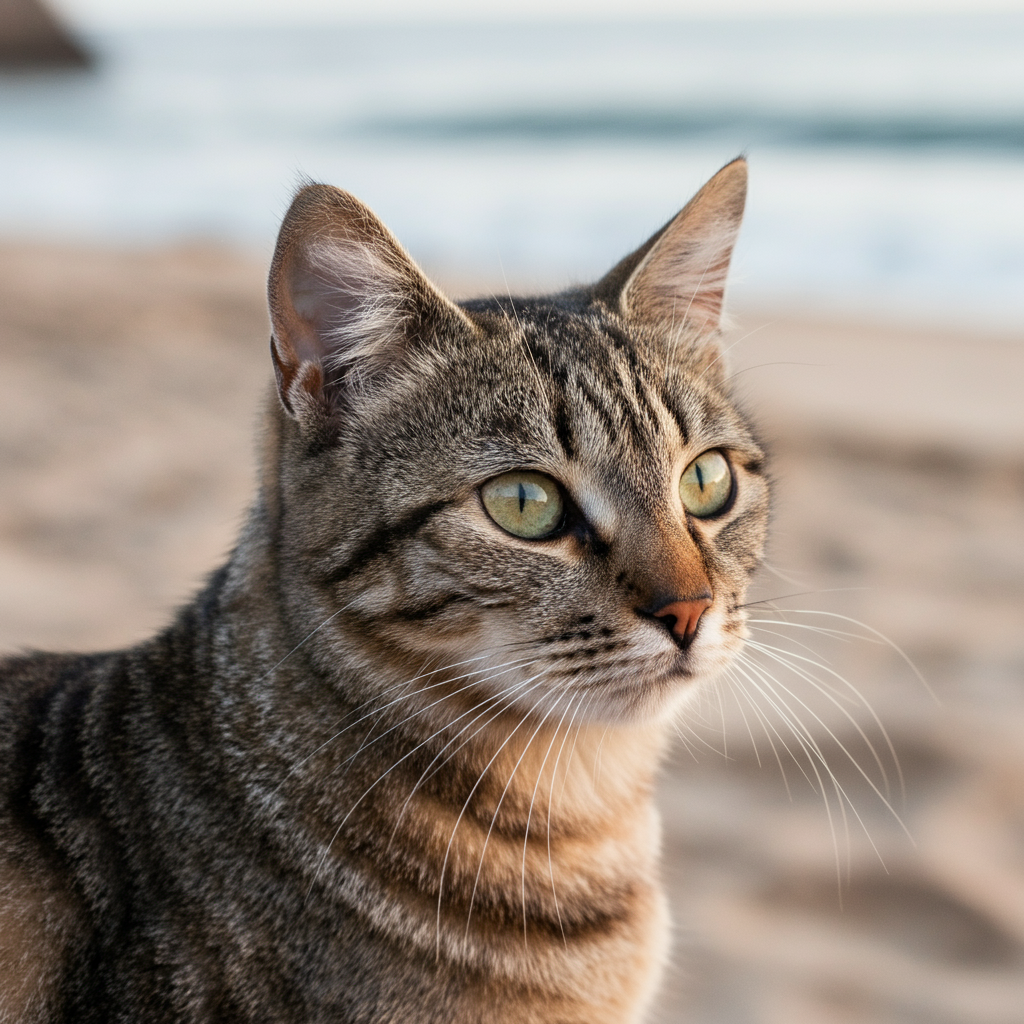

In [ ]:
############################################
# Run Imagen Request
############################################

async def run_standalone_test(prompt):
    # Create a fresh session
    session = await session_service.create_session(app_name="standalone-app", user_id="user-123")
    user_msg = genai_types.Content(role="user", parts=[genai_types.Part.from_text(text=prompt)])

    print(f"📡 Sending request: {prompt}")

    # Clear out any old images before running
    if os.path.exists("output_image.png"):
        os.remove("output_image.png")

    async for event in runner.run_async(
        user_id="user-123",
        session_id=session.id,
        new_message=user_msg
    ):
        # Print Text parts
        if event.is_final_response() and event.content.parts:
             print(f"🕵️ Assistant: {event.content.parts[0].text}")

    # Display the image from the local disk
    if os.path.exists("output_image.png"):
        print("✨ Image Generated:")
        display(Image(filename="output_image.png"))

# EXECUTE
await run_standalone_test("Create an image of a cat at a beach")

In [ ]:
############################################
# Run Veo Request
############################################
from google.genai import types as genai_types

async def run_standalone_test(prompt):
    # Create a fresh session
    session = await session_service.create_session(app_name="standalone-app", user_id="user-123")
    user_msg = genai_types.Content(role="user", parts=[genai_types.Part.from_text(text=prompt)])

    print(f"📡 Sending request: {prompt}")

    # We removed the local output_image.png check here because
    # we might be asking for a video which goes to Cloud Storage!

    async for event in runner.run_async(
        user_id="user-123",
        session_id=session.id,
        new_message=user_msg
    ):
        # Print Text parts
        if event.is_final_response() and event.content.parts:
             print(f"🕵️ Assistant: {event.content.parts[0].text}")

# EXECUTE
await run_standalone_test("Create a short video of a cat at a beach")

📡 Sending request: Create a short video of a cat at a beach
🕵️ Assistant: I've started generating a video of a cat at a beach for you! It will be saved to your Cloud Storage bucket.


###### ⬜ *Cloud Run: MCP and BigQuery (with OAuth2)*

The Concept: Moving to the Cloud

Right now, your architecture is entirely local to your Colab notebook. The AI agent and the BigQuery tool server are running on the exact same temporary machine. When you close the browser, both die.

By bringing MCP to the cloud, we are decoupling them.

* The Server (Cloud Run): We will package your BigQuery Python function into a secure, serverless container on Google Cloud. It will sleep when not in use (costing $0) and wake up instantly when queried. It will have a permanent, secure https:// URL.

* The Client (Colab): Your notebook will simply act as a remote control. It will ask Google for a secure ID badge (an authentication token), knock on the Cloud Run server's door, and ask it to execute queries over the internet.

**Step 1: The New FastMCP Server Code**

FastMCP removes the need to manually wire up Uvicorn, Starlette, SSE routes, and JSON schemas. Notice how much smaller and cleaner this is than your previous code!

In [ ]:
%%writefile bq_server.py
from mcp.server.fastmcp import FastMCP
from google.cloud import bigquery

# 1. Initialize FastMCP
mcp = FastMCP("bigquery-analyst")

# 2. Define the Tool using a simple decorator
@mcp.tool()
def query_public_dataset(sql_query: str) -> str:
    """Run a read-only SQL query against BigQuery public datasets."""
    forbidden = ["DROP", "DELETE", "INSERT", "UPDATE", "ALTER", "TRUNCATE"]
    if any(cmd in sql_query.upper() for cmd in forbidden):
        return "Error: Modification queries are not allowed. Read-only access."

    try:
        # Cloud Run automatically handles the authentication for this client!
        client = bigquery.Client()
        query_job = client.query(sql_query)

        results = [dict(row) for row in query_job.result()]
        if not results:
            return "Query executed successfully but returned no results."
        return str(results[:20])
    except Exception as e:
        return f"BigQuery Error: {str(e)}"

# 3. Expose the ASGI app for the web server
app = mcp.sse_app()

Overwriting bq_server.py


**Step 2: Configure the Deployment**

To deploy this to Cloud Run, Google needs to know exactly what libraries to install and how to start the app.

In [ ]:
%%writefile requirements.txt
uvicorn
mcp
google-cloud-bigquery

Writing requirements.txt


In [ ]:
%%writefile Procfile
web: uvicorn bq_server:app --host 0.0.0.0 --port $PORT

Writing Procfile


The problem is the --source . part of your command. In Linux, . means "the current directory."

By running that in Colab, you accidentally told Google Cloud to package up your entire Colab workspace (/content/). This includes Google's hidden .config folders, the default sample_data folder, your old server.log, and any old keys you tried to make. The Cloud Buildpack looks at all that unrelated junk, gets completely confused about what kind of app you are trying to build, and crashes the build.

The Fix: Isolate the App: We need to put our 3 files into their own clean, isolated folder, and tell Cloud Run to deploy only that folder. Let's do this the clean way.

Run this block to create a dedicated folder and write all our files directly into it:

In [ ]:
import os

# 1. Create the clean directory
os.makedirs("my_cloud_mcp", exist_ok=True)

# 2. Write the Python Server Code
server_code = """from mcp.server.fastmcp import FastMCP
from google.cloud import bigquery

mcp = FastMCP("bigquery-analyst")

@mcp.tool()
def query_public_dataset(sql_query: str) -> str:
    \"\"\"Run a read-only SQL query against BigQuery public datasets.\"\"\"
    forbidden = ["DROP", "DELETE", "INSERT", "UPDATE", "ALTER", "TRUNCATE"]
    if any(cmd in sql_query.upper() for cmd in forbidden):
        return "Error: Modification queries are not allowed. Read-only access."

    try:
        client = bigquery.Client()
        query_job = client.query(sql_query)

        results = [dict(row) for row in query_job.result()]
        if not results:
            return "Query executed successfully but returned no results."
        return str(results[:20])
    except Exception as e:
        return f"BigQuery Error: {str(e)}"

# Expose the ASGI app for the web server
app = mcp.sse_app()
"""
with open("my_cloud_mcp/bq_server.py", "w") as f:
    f.write(server_code)

# 3. Write requirements.txt
requirements_code = """uvicorn
starlette
sse-starlette
mcp
google-cloud-bigquery
"""
with open("my_cloud_mcp/requirements.txt", "w") as f:
    f.write(requirements_code)

# 4. Write the Procfile
procfile_code = "web: uvicorn bq_server:app --host 0.0.0.0 --port $PORT"
with open("my_cloud_mcp/Procfile", "w") as f:
    f.write(procfile_code)

print("✅ Successfully created my_cloud_mcp folder and all files!")

✅ Successfully created my_cloud_mcp folder and all files!


**Step 3: Secure Deployment (No Keys Needed!)**

Remember that FAILED_PRECONDITION error you got trying to download a Service Account key? We are going to bypass that completely. Because Cloud Run is a native Google service, we just assign the Service Account directly to the container.

Run this deployment command. Notice we are using --no-allow-unauthenticated. This locks down your server so only you can access it.

Note: This step will take 2-3 minutes as Google builds the Docker container for you in the background and deploys it.

In [ ]:
PROJECT_ID = "lunar-352813"

!gcloud run deploy bq-mcp-analyst \
    --source my_cloud_mcp/ \
    --platform managed \
    --region us-central1 \
    --service-account="bq-mcp-analyst@{PROJECT_ID}.iam.gserviceaccount.com" \
    --no-allow-unauthenticated \
    --project={PROJECT_ID} \
    --quiet

Building using Buildpacks and deploying container to Cloud Run service [bq-mcp-analyst] in project [lunar-352813] region [us-central1]
Service [bq-mcp-analyst] revision [bq-mcp-analyst-00001-vq4] has been deployed and is serving 100 percent of traffic.
Service URL: https://bq-mcp-analyst-892203813305.us-central1.run.app


**Step 4: Securely Connect the ADK Agent and Run Request**

Once the deployment finishes, the terminal will print out a Service URL (it will look something like https://bq-mcp-analyst-xyz-uc.a.run.app). Because we locked down the server for security, your Colab notebook needs to generate an Identity Token to prove who it is before connecting. **Copy your new Cloud Run URL and run this block in Cloud Shell Editor:**

In [ ]:
# Create the Client Script
# In Cloud Shell Editor, create a new file named agent_client.py and paste this complete flow into it:
import asyncio
import time
import google.auth.transport.requests
import google.oauth2.id_token
from google.adk.tools.mcp_tool import SseConnectionParams, MCPToolset
from google.adk.agents import LlmAgent
from google.adk.runners import Runner
from google.adk.sessions import InMemorySessionService
from google.genai import types as genai_types

async def run_agent():
    # 1. Define Cloud Run URL
    CLOUD_RUN_URL = "https://bq-mcp-analyst-892203813305.us-central1.run.app"

    print("🔑 Fetching secure ID token from Cloud Shell metadata...")
    auth_req = google.auth.transport.requests.Request()
    secure_token = google.oauth2.id_token.fetch_id_token(auth_req, CLOUD_RUN_URL)

    # 2. Set up MCP Connection
    remote_bq_params = SseConnectionParams(
        url=f"{CLOUD_RUN_URL}/sse",
        headers={"Authorization": f"Bearer {secure_token}"}
    )
    mcp_bq_tools = MCPToolset(connection_params=remote_bq_params)
    print("✅ Successfully authenticated with Cloud Run MCP server!")

    # 3. Create Agent
    enterprise_agent = LlmAgent(
        name='bigquery_analyst',
        model='gemini-2.0-flash',
        instruction="""
        You are an Enterprise Data Analyst.
        You have access to Google BigQuery public datasets.
        When asked a question:
        1. Formulate a correct BigQuery SQL query.
        2. Use the 'query_public_dataset' tool to execute it.
        3. Summarize the findings for the user.
        """,
        tools=[mcp_bq_tools]
    )

    # 4. Initialize Runner and Session
    session_service = InMemorySessionService()
    APP_NAME = "bq-demo-app"
    USER_ID = "cloud-shell-user"

    bq_runner = Runner(
        agent=enterprise_agent,
        session_service=session_service,
        app_name=APP_NAME,
    )

    print("🔄 Creating ADK session...")
    try:
        new_session = await session_service.create_session(
            app_name=APP_NAME,
            user_id=USER_ID
        )
        active_session_id = new_session.id
    except Exception as e:
        print(f"❌ Failed to create session. Error: {e}")
        return

    # 5. Ask the Question
    question = "What were the top 3 most popular female names in the USA in 1980? Query the 'bigquery-public-data.usa_names.usa_1910_2013' table."
    print(f"\n🤖 User: {question}\n")

    user_msg = genai_types.Content(
        role="user",
        parts=[genai_types.Part.from_text(text=question)]
    )

    # 6. Run the Execution Loop
    try:
        async for event in bq_runner.run_async(
            user_id=USER_ID,
            session_id=active_session_id,
            new_message=user_msg
        ):
            if event.is_final_response() and event.content:
                if event.content.parts:
                    print(f"🕵️ Analyst: {event.content.parts[0].text}")
    finally:
        # Clean up the MCP connection cleanly before the script exits
        await bq_runner.close()
        print("\n🔌 Runner and MCP session closed safely.")

if __name__ == "__main__":
    # Standard Python requires an explicit event loop
    asyncio.run(run_agent())

In [ ]:
# Run first in cloud shell editor:
pip install google-adk google-genai google-auth

# then run:
python agent_client.py

# error analy

troubleshoot

In [ ]:
gcloud config list

admin_@cloudshell:~ (lunar-352813)$ gcloud config list
Project 'lunar-352813' lacks an 'environment' tag. Please create or add a tag with key 'environment' and a value like 'Production', 'Development', 'Test', or 'Staging'. Add an 'environment' tag using `gcloud resource-manager tags bindings create`. See https://cloud.google.com/resource-manager/docs/creating-managing-projects#designate_project_environments_with_tags for details.
[accessibility]
screen_reader = True
[component_manager]
disable_update_check = True
[compute]
gce_metadata_read_timeout_sec = 30
[core]
account =
disable_usage_reporting = False
project = lunar-352813
universe_domain = googleapis.com
[metrics]
environment = devshell

Your active configuration is: [cloudshell-27714]



In [ ]:
gcloud auth list

admin_@cloudshell:~ (lunar-352813)$ gcloud auth list
Credentialed Accounts

ACTIVE:
ACCOUNT: admin@deltorobarba.altostrat.com

To set the active account, run:
    $ gcloud config set account `ACCOUNT`

In [ ]:
gcloud config set account admin@deltorobarba.altostrat.com
Updated property [core/account].


In [ ]:
gcloud auth application-default login

In [ ]:
# reauthentiocate CLI
gcloud auth login

In [ ]:
# deploy server
gcloud run deploy bq-mcp-analyst \
    --source my_cloud_mcp/ \
    --platform managed \
    --region us-central1 \
    --no-allow-unauthenticated \
    --quiet

In [ ]:
# run script
python agent_client.py